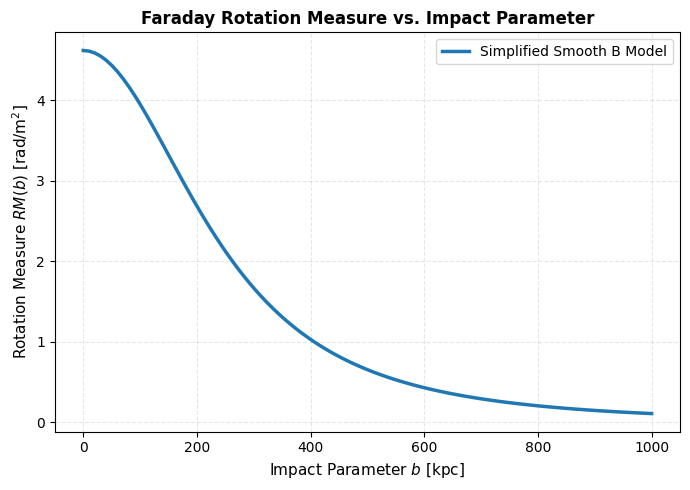

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# 1. Core Cluster Parameters (Coma Cluster Constants)
n0 = 3e-3         # Central electron density [cm^-3]
B0 = 4.0          # Central magnetic field [microGauss]
rc = 291.0        # Core radius [kpc]
beta = 0.75       # Density profile index
eta = 0.67        # Magnetic field scaling index

# Integration limits along the line of sight (z goes from -L to +L)
L = 1000.0        # Integration boundary [kpc]
N_z = 2000        # Resolution steps along the line of sight
z_arr = np.linspace(-L, L, N_z)

# 2. Define the Physical Profile Functions
def get_ne(r):
    """Calculates electron density at a 3D radius r"""
    return n0 * (1 + (r / rc)**2)**(-1.5 * beta)

def get_B_parallel(r):
    """Calculates the simplified, smooth parallel magnetic field component"""
    return B0 * (get_ne(r) / n0)**eta

# 3. Compute RM for a Range of Impact Parameters (b)
b_arr = np.linspace(0.0, 1000.0, 100) # Impact parameters from core to 1 Mpc [kpc]
RM_vs_b = []

for b in b_arr:
    # Coordinate Transformation Matrix: Calculate 3D radius r for every point along this LOS
    r_arr = np.sqrt(b**2 + z_arr**2)
    
    # Evaluate the physical fluid values along this specific sightline
    ne_z = get_ne(r_arr)
    B_parallel_z = get_B_parallel(r_arr)
    
    # Calculate the integrand: n_e * B_parallel
    integrand = ne_z * B_parallel_z
    
    # Integrate along the z-axis using the trapezoidal rule
    # Scale factor 0.812 accounts for the astrophysical unit conversions
    RM_at_b = 0.812 * trapezoid(integrand, z_arr)
    
    # Store the result for this impact parameter
    RM_vs_b.append(RM_at_b)

# 4. Plotting the Observable Radial Map
plt.figure(figsize=(7, 5))
plt.plot(b_arr, RM_vs_b, color='tab:blue', lw=2.5, label='Simplified Smooth B Model')
plt.xlabel(r'Impact Parameter $b$ [kpc]', fontsize=11)
plt.ylabel(r'Rotation Measure $RM(b)$ [$\text{rad/m}^2$]', fontsize=11)
plt.title('Faraday Rotation Measure vs. Impact Parameter', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

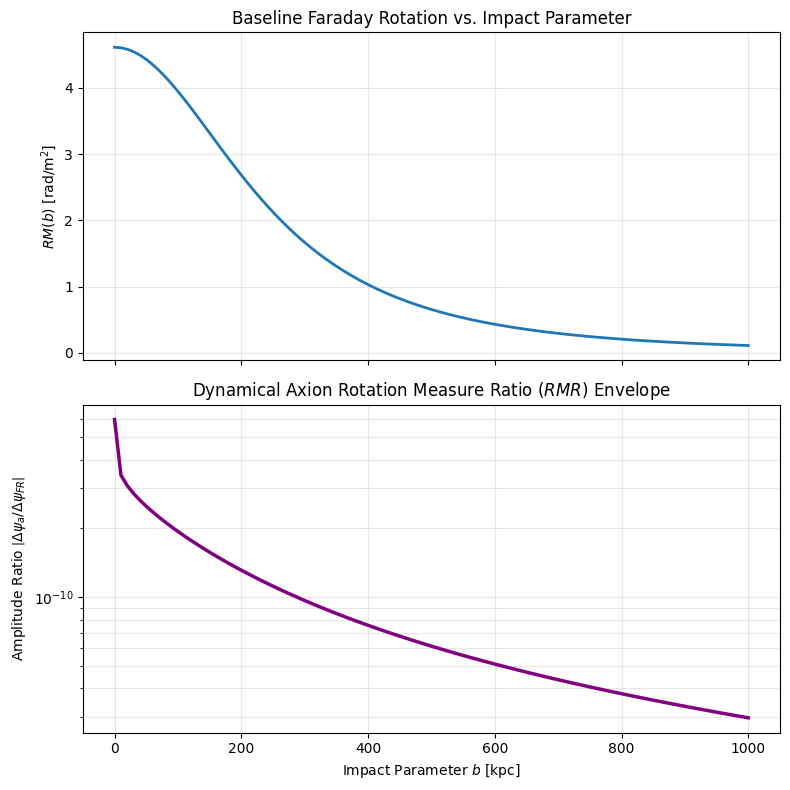

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# --- Conversion Factors to Natural Units (eV) ---
kpc_to_cm = 3.086e21
cm_to_eV_inv = 1.973e-5
kpc_to_eV_inv = kpc_to_cm / cm_to_eV_inv

# 1. Physical Parameters
n0 = 3e-3         # cm^-3
B0 = 4.0          # microGauss
rc = 291.0        # kpc
beta = 0.75
eta = 0.67

rho_0 = 1e-25     # g/cm^3
Rs = 400.0        # kpc
m_a = 1e-27       # eV

# Grid Setup
L = 1000.0        # half-length [kpc]
z_arr = np.linspace(-L, L, 2000)
b_arr = np.linspace(0.0, 1000.0, 100) # Impact parameters [kpc]

# 2. Profiles & Derivative Functions
def get_ne_profile(r):
    return (1 + (r / rc)**2)**(-1.5 * beta)

def get_ne(r):
    return n0 * get_ne_profile(r)

def get_B_parallel(r):
    return B0 * (get_ne(r) / n0)**eta

def get_a0(r):
    r_safe = np.maximum(r, 1e-9)
    rho_DM = rho_0 / ((r_safe / Rs) * (1 + r_safe / Rs)**2)
    return np.sqrt(2 * rho_DM) / m_a

def get_da_dr(r):
    r_safe = np.maximum(r, 1e-9)
    term1 = -0.5 * (r_safe / Rs)**-1.5 * (1 + r_safe / Rs)**-1
    term2 = -1.0 * (r_safe / Rs)**-0.5 * (1 + r_safe / Rs)**-2
    da_dr_kpc = (np.sqrt(2 * rho_0) / (m_a * Rs)) * (term1 + term2)
    return da_dr_kpc / kpc_to_eV_inv

# 3. Processing the Integrals
RM_vs_b = []
Axion_vs_b = []

for b in b_arr:
    # Coordinate Engine
    r_arr = np.sqrt(b**2 + z_arr**2)
    
    # --- Faraday Component ---
    ne_z = get_ne(r_arr)
    B_par_z = get_B_parallel(r_arr)
    fr_integrand = ne_z * B_par_z
    RM_vs_b.append(0.812 * trapezoid(fr_integrand, z_arr))
    
    # --- Dynamical Axion Component ---
    da_dr_z = get_da_dr(r_arr)
    a0_z = get_a0(r_arr)
    
    # Spatial derivative envelope (cos -> 1)
    da_dz_envelope = da_dr_z * (z_arr / (r_arr + 1e-9))
    
    # Time derivative envelope (sin -> 1)
    da_dt_envelope = -m_a * a0_z
    
    # Combined upper-bound amplitude profile for the axion field change
    # (Using the shape profile ne_z/n0 since absolute constants cancel in the ratio later)
    axion_field_combination = np.abs(da_dz_envelope) + np.abs(da_dt_envelope)
    
    # Axion effect scales with local plasma conditions (ne) and local field (B)
    axion_integrand = (ne_z / n0) * axion_field_combination * B_par_z
    Axion_vs_b.append(trapezoid(axion_integrand, z_arr))

# Convert to arrays for division
RM_vs_b = np.array(RM_vs_b)
Axion_vs_b = np.array(Axion_vs_b)

# Calculate the clean Rotation Measure Ratio
# (Prefactors cancel, leaving the structural ratio)
RMR_vs_b = Axion_vs_b / (RM_vs_b + 1e-12)

# 4. Plotting the Comparison Envelopes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(b_arr, RM_vs_b, color='tab:blue', lw=2, label='Faraday Rotation Measure')
ax1.set_ylabel(r'$RM(b)$ [$\text{rad/m}^2$]')
ax1.set_title('Baseline Faraday Rotation vs. Impact Parameter')
ax1.grid(True, alpha=0.3)

ax2.plot(b_arr, RMR_vs_b, color='purple', lw=2.5, label='RMR Envelope')
ax2.set_yscale('log')
ax2.set_xlabel(r'Impact Parameter $b$ [kpc]')
ax2.set_ylabel(r'Amplitude Ratio $\left|\Delta\psi_a / \Delta\psi_{FR}\right|$')
ax2.set_title('Dynamical Axion Rotation Measure Ratio ($RMR$) Envelope')
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

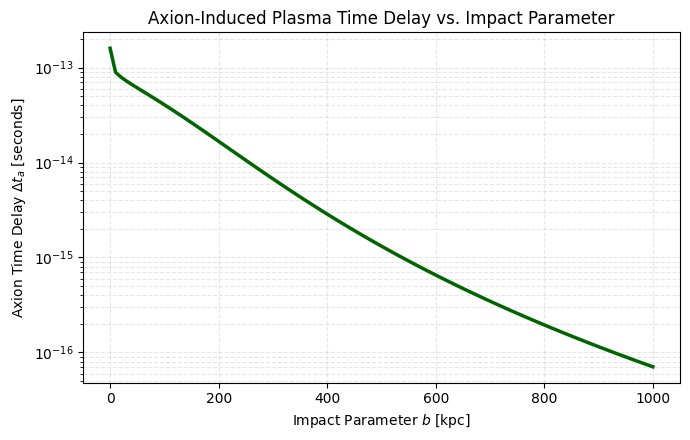

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# --- Physical & Conversion Constants (SI & Natural Units) ---
hz_to_eV = 4.135667696e-15
kpc_to_meters = 3.086e19
speed_of_light = 3e8  # m/s

kpc_to_cm = 3.086e21
cm_to_eV_inv = 1.973e-5
kpc_to_eV_inv = kpc_to_cm / cm_to_eV_inv

# --- Cluster & Axion Parameters ---
n0 = 3e-3          # cm^-3
rc = 291.0         # kpc
beta = 0.75
rho_0 = 1e-25      # g/cm^3
Rs = 400.0         # kpc
m_a = 1e-27        # eV

# --- Observational Constraints ---
f0_SI = 54e6       # LOFAR frequency (54 MHz)
k0 = f0_SI * hz_to_eV 
g_agg = 0.66 * 1e-10 * 1e-9  # eV^-1 (from 0.66 x 1e-10 GeV^-1)

# Grid setup
L = 1000.0         # kpc
z_arr = np.linspace(-L, L, 2000)
b_arr = np.linspace(0.0, 1000.0, 100)

def get_ne(r):
    return n0 * (1 + (r / rc)**2)**(-1.5 * beta)

def get_wp_squared_eV2(r):
    # Standard relation for plasma frequency squared in eV^2
    ne_cm3 = get_ne(r)
    ne_SI = ne_cm3 * 1e6  # m^-3
    # wp^2 = (ne * e^2) / (epsilon_0 * m_e)
    wp_SI_sq = ne_SI * 3182.6  
    return (wp_SI_sq * hz_to_eV)**2

def get_a0(r):
    r_safe = np.maximum(r, 1e-9)
    rho_DM = rho_0 / ((r_safe / Rs) * (1 + r_safe / Rs)**2)
    return np.sqrt(2 * rho_DM) / m_a

def get_da_dr(r):
    r_safe = np.maximum(r, 1e-9)
    term1 = -0.5 * (r_safe / Rs)**-1.5 * (1 + r_safe / Rs)**-1
    term2 = -1.0 * (r_safe / Rs)**-0.5 * (1 + r_safe / Rs)**-2
    da_dr_kpc = (np.sqrt(2 * rho_0) / (m_a * Rs)) * (term1 + term2)
    return da_dr_kpc / kpc_to_eV_inv

# --- Calculate Time Delay Envelope ---
time_delays = []

for b in b_arr:
    r_arr = np.sqrt(b**2 + z_arr**2)
    
    wp2 = get_wp_squared_eV2(r_arr)
    da_dr = get_da_dr(r_arr)
    a0 = get_a0(r_arr)
    
    da_dz = np.abs(da_dr * (z_arr / (r_arr + 1e-9)))
    da_dt = np.abs(-m_a * a0)
    
    # Combined upper-bound envelope (sin -> 1, cos -> 1)
    integrand_eV = (wp2 / k0**2) * (g_agg / (4 * k0)) * (da_dz + da_dt)
    
    # Integrate along z in eV^-1
    integrand_eV_inv = integrand_eV * kpc_to_eV_inv
    total_delay_eV_inv = trapezoid(integrand_eV_inv, z_arr)
    
    # Convert natural units (eV^-1) back to physical seconds
    total_delay_seconds = total_delay_eV_inv * 6.582119569e-16
    time_delays.append(total_delay_seconds)

# --- Plotting Time Delay ---
plt.figure(figsize=(7, 4.5))
plt.plot(b_arr, time_delays, color='darkgreen', lw=2.5)
plt.yscale('log')
plt.xlabel(r'Impact Parameter $b$ [kpc]')
plt.ylabel(r'Axion Time Delay $\Delta t_a$ [seconds]')
plt.title('Axion-Induced Plasma Time Delay vs. Impact Parameter')
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [4]:
def calculate_axion_birefringence_vs_b(b_range, z_limit=1000.0, nz_steps=2000):
    """
    Computes the total axion birefringence phase shift amplitude 
    as a function of the impact parameter (b).
    
    Parameters:
        b_range (array): 1D array of impact parameters [kpc]
        z_limit (float): Half-length of the line-of-sight integration axis [kpc]
        nz_steps (int): Number of numerical sampling intervals along z
        
    Returns:
        b_range (array): The input impact parameters
        birefringence_profile (array): Phase shift delta_psi_a per unit coupling/field strength
    """
    z_axis = np.linspace(-z_limit, z_limit, nz_steps)
    birefringence_profile = []
    
    for b in b_range:
        # Coordinate engine mapping to 3D shell radius
        r_path = np.sqrt(b**2 + z_axis**2)
        
        # Local plasma density scaling profile (normalized shape)
        ne_weight = (1 + (r_path / rc)**2)**(-1.5 * beta)
        
        # Local baseline magnetic field amplitude profile scaling
        B_amp_weight = ne_weight**eta
        
        # Pull spatial NFW field structural parameters
        a0 = get_a0(r_path)
        da_dr = get_da_dr(r_path)
        
        # Apply maximal envelope transformation (cos -> 1, sin -> 1)
        da_dz_env = np.abs(da_dr * (z_axis / (r_path + 1e-9)))
        da_dt_env = np.abs(-m_a * a0)
        
        # Total amplitude metric variation inside the domain
        axion_amplitude_factor = da_dz_env + da_dt_env
        
        # The phase change requires local plasma density weight * axion gradient * B_perp.
        # Assuming smooth B configuration for this module layer.
        birefringence_integrand = ne_weight * axion_amplitude_factor * B_amp_weight
        
        # Integrate across the entire LOS path length slice
        integrated_phase = trapezoid(birefringence_integrand, z_axis)
        birefringence_profile.append(integrated_phase)
        
    return np.array(b_range), np.array(birefringence_profile)

# Example Usage:
# b_axes, phase_shifts = calculate_axion_birefringence_vs_b(np.linspace(0, 1000, 100))

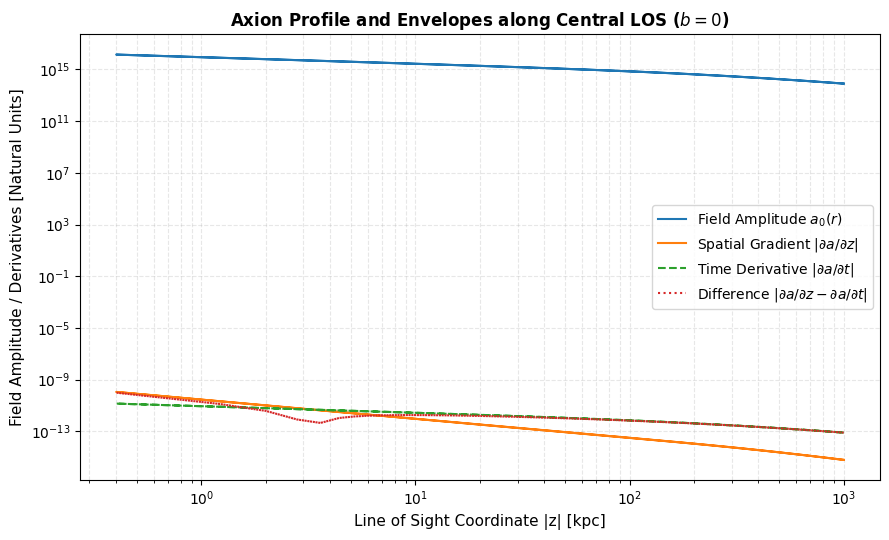

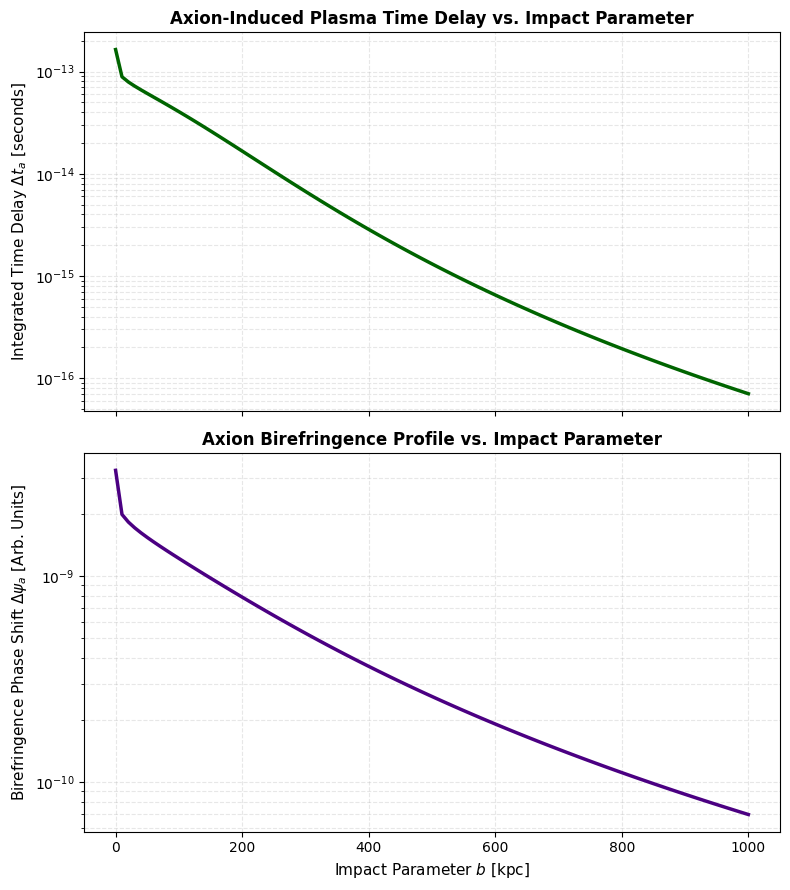

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# =====================================================================
# 1. PHYSICAL CONSTANTS & CONVERSION FACTORS (SI & NATURAL UNITS)
# =====================================================================
hz_to_eV = 4.135667696e-15
kpc_to_cm = 3.086e21
cm_to_eV_inv = 1.973e-5
kpc_to_eV_inv = kpc_to_cm / cm_to_eV_inv  # 1 kpc in units of 1/eV
eV_inv_to_seconds = 6.582119569e-16

# --- Coma Cluster Medium Parameters ---
n0 = 3e-3          # Central gas density [cm^-3]
B0 = 4.0           # Central magnetic field [microGauss]
rc = 291.0         # Core radius [kpc]
beta = 0.75        # Density profile index
eta = 0.67         # B-field scaling index

# --- Dark Matter & Axion Parameters ---
rho_0 = 1e-25      # NFW scale density [g/cm^3]
Rs = 400.0         # NFW scale radius [kpc]
m_a = 1e-27        # Axion mass [eV]

# --- Observation Parameters ---
f0_SI = 54e6       # LOFAR observation frequency (54 MHz)
k0 = f0_SI * hz_to_eV 
g_agg = 0.66 * 1e-10 * 1e-9  # Coupling constant converted to eV^-1

# --- Numerical Grid Setup ---
L = 1000.0         # Half-length of Line of Sight [kpc]
N_z = 2500         # Resolution steps along z
z_arr = np.linspace(-L, L, N_z)
b_arr = np.linspace(0.1, 1000.0, 100) # Impact parameters from near-core out to 1 Mpc

# =====================================================================
# 2. PROFILE & GRADIENT DEFINITIONS
# =====================================================================
def get_a0(r):
    """Calculates 3D Axion field amplitude from NFW density profile"""
    r_safe = np.maximum(r, 1e-9)
    rho_DM = rho_0 / ((r_safe / Rs) * (1 + r_safe / Rs)**2)
    return np.sqrt(2 * rho_DM) / m_a

def get_da_dr(r):
    """Calculates analytical radial derivative da/dr (converted to eV^2)"""
    r_safe = np.maximum(r, 1e-9)
    term1 = -0.5 * (r_safe / Rs)**-1.5 * (1 + r_safe / Rs)**-1
    term2 = -1.0 * (r_safe / Rs)**-0.5 * (1 + r_safe / Rs)**-2
    da_dr_kpc = (np.sqrt(2 * rho_0) / (m_a * Rs)) * (term1 + term2)
    return da_dr_kpc / kpc_to_eV_inv

def get_wp_squared_eV2(r):
    """Calculates plasma frequency squared in natural units (eV^2)"""
    ne_m3 = get_ne(r) * 1e6  # Convert cm^-3 to m^-3
    wp_SI_sq = ne_m3 * 3182.6  # Standard plasma constant mapping
    return (wp_SI_sq * hz_to_eV)**2

def get_ne(r):
    return n0 * (1 + (r / rc)**2)**(-1.5 * beta)

# =====================================================================
# STAGE 1: AXION FIELD & DERIVATIVES ALONG THE LINE OF SIGHT (b = 0)
# =====================================================================
# For checking baseline profiles, we set b = 0 (skimming through the core)
b_core = 0.0
r_core = np.sqrt(b_core**2 + z_arr**2)

a0_line = get_a0(r_core)
da_dr_line = get_da_dr(r_core)

# Compute exact partial derivatives with respect to space (z) and time (t)
da_dz_line = np.abs(da_dr_line * (z_arr / (r_core + 1e-9)))
da_dt_line = np.abs(-m_a * a0_line)
difference_line = np.abs(da_dz_line - da_dt_line)

# --- Plot 1: Line-of-Sight Profile Comparison ---
plt.figure(figsize=(9, 5.5))
plt.loglog(np.abs(z_arr), a0_line, label=r'Field Amplitude $a_0(r)$', color='tab:blue', lw=1.5)
plt.loglog(np.abs(z_arr), da_dz_line, label=r'Spatial Gradient $|\partial a / \partial z|$', color='tab:orange')
plt.loglog(np.abs(z_arr), da_dt_line, label=r'Time Derivative $|\partial a / \partial t|$', color='tab:green', linestyle='--')
plt.loglog(np.abs(z_arr), difference_line, label=r'Difference $|\partial a / \partial z - \partial a / \partial t|$', color='tab:red', linestyle=':')

plt.xlabel('Line of Sight Coordinate |z| [kpc]', fontsize=11)
plt.ylabel('Field Amplitude / Derivatives [Natural Units]', fontsize=11)
plt.title(r'Axion Profile and Envelopes along Central LOS ($b=0$)', fontsize=12, fontweight='bold')
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# =====================================================================
# STAGES 2 & 3: TIME DELAY AND BIREFRINGENCE VS. IMPACT PARAMETER (b)
# =====================================================================
time_delays_vs_b = []
birefringence_vs_b = []

for b in b_arr:
    # Coordinate Engine mapping to 3D trajectory shell
    r_arr = np.sqrt(b**2 + z_arr**2)
    
    # Environment lookups
    wp2_z = get_wp_squared_eV2(r_arr)
    ne_z = get_ne(r_arr)
    B_z = B0 * (ne_z / n0)**eta  # Smooth parallel field profile proxy
    
    # Axion profile inputs
    a0_z = get_a0(r_arr)
    da_dr_z = get_da_dr(r_arr)
    
    # Partials calculations
    da_dz_z = np.abs(da_dr_z * (z_arr / (r_arr + 1e-9)))
    da_dt_z = np.abs(-m_a * a0_z)
    
    # Maximize upper bound envelope values (sin -> 1, cos -> 1)
    axion_envelope = da_dz_z + da_dt_z
    
    # --- 1. Compute Integrated Time Delay ---
    # dt prop-to: integral (wp^2 / k0^2) * (g_agg / 4k0) * (da/dz - da/dt) dz
    dt_integrand_eV = (wp2_z / k0**2) * (g_agg / (4 * k0)) * axion_envelope
    dt_integrand_eV_inv = dt_integrand_eV * kpc_to_eV_inv
    total_dt_eV_inv = trapezoid(dt_integrand_eV_inv, z_arr)
    total_dt_seconds = total_dt_eV_inv * eV_inv_to_seconds
    time_delays_vs_b.append(total_dt_seconds)
    
    # --- 2. Compute Integrated Birefringence Phase Shift ---
    # delta_psi prop-to: integral (da/dz - da/dt) * B_perp * dz
    # Here we track relative changes using the spatial magnetic distribution weight
    biref_integrand = axion_envelope * B_z
    total_biref_phase = trapezoid(biref_integrand, z_arr)
    birefringence_vs_b.append(total_biref_phase)

# =====================================================================
# 4. PLOTTING THE MACROSCOPIC 2D SKY PROJECTIONS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

# --- Plot 2: Time Delay Map ---
ax1.plot(b_arr, time_delays_vs_b, color='darkgreen', lw=2.5)
ax1.set_yscale('log')
ax1.set_ylabel(r'Integrated Time Delay $\Delta t_a$ [seconds]', fontsize=11)
ax1.set_title('Axion-Induced Plasma Time Delay vs. Impact Parameter', fontsize=12, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3, linestyle='--')

# --- Plot 3: Birefringence Phase Shift Map ---
ax2.plot(b_arr, birefringence_vs_b, color='indigo', lw=2.5)
ax2.set_yscale('log')
ax2.set_xlabel(r'Impact Parameter $b$ [kpc]', fontsize=11)
ax2.set_ylabel(r'Birefringence Phase Shift $\Delta \psi_a$ [Arb. Units]', fontsize=11)
ax2.set_title('Axion Birefringence Profile vs. Impact Parameter', fontsize=12, fontweight='bold')
ax2.grid(True, which='both', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()